# 1. Programmation dynamique exacte

Vérité terrain du problème de pricing dynamique : on résout le MDP *exactement* par une récursion arrière (le problème est acyclique en `t`), puis on vérifie que la solution respecte les propriétés structurelles prédites par la théorie du revenue management. Cette étape doit être validée avant d'introduire le moindre bruit d'apprentissage (Q-learning, notebook 2).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)


## 1.1 Vérification préalable de la courbe de demande

Le revenu espéré par période $p \cdot \lambda(p)$ doit avoir un maximum **intérieur** à la grille de prix. S'il est monotone, il n'y a aucun arbitrage prix/probabilité de vente à apprendre et le projet est dégénéré.

Prix optimal statique (myope) : 90.0, à l'indice 8/19 de la grille


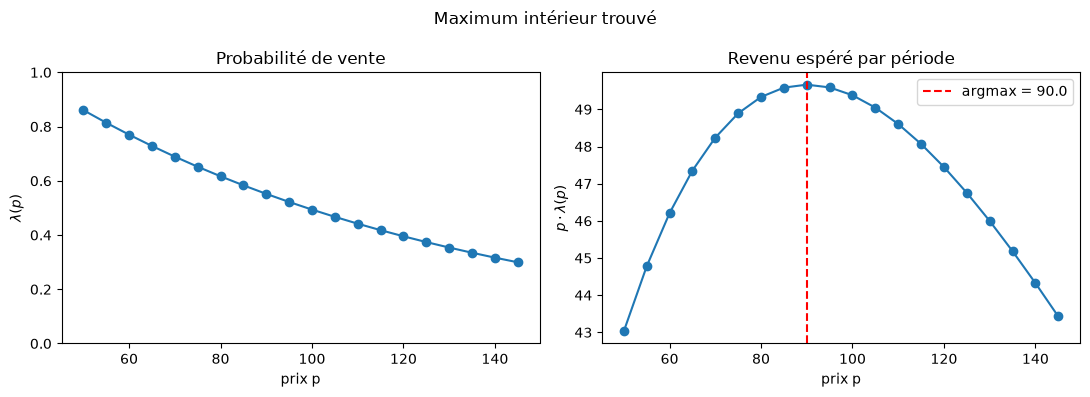

In [2]:
from src.config import DEFAULT_CONFIG
from src.demand import assert_interior_maximum, plot_demand_curve

cfg = DEFAULT_CONFIG
argmax_idx = assert_interior_maximum(cfg)  # lève une erreur explicite si dégénéré
print(f"Prix optimal statique (myope) : {cfg.prices[argmax_idx]:.1f}, "
      f"à l'indice {argmax_idx}/{cfg.K - 1} de la grille")

fig = plot_demand_curve(cfg, savepath=OUT / "demand_curve.png")
plt.show()

## 1.2 Résolution exacte par récursion arrière

$$Q^*(c,t,p) = \lambda(p)\big[p + \gamma V^*(c-1,t-1)\big] + (1-\lambda(p))\,\gamma V^*(c,t-1), \qquad V^*(c,t) = \max_p Q^*(c,t,p)$$

avec $V^*(c,0) = V^*(0,t) = 0$. Une seule passe sur $t=1,\dots,T$, vectorisée sur $c$ et $p$.

In [3]:
import time
from src.dp import solve_dp

t0 = time.perf_counter()
Q_star, V_star, pi_idx = solve_dp(cfg)
elapsed = time.perf_counter() - t0

print(f"Temps de résolution : {elapsed*1000:.1f} ms")
print(f"Q* shape = {Q_star.shape}, V* shape = {V_star.shape}")
print(f"V*(C,T) = {V_star[cfg.C, cfg.T]:.2f}  (revenu optimal espéré total)")

Temps de résolution : 7.8 ms
Q* shape = (51, 201, 20), V* shape = (51, 201)
V*(C,T) = 986.52  (revenu optimal espéré total)


## 1.3 Tests de validation structurelle (non optionnels)

1. $V^*(c,t)$ concave en $c$
2. $V^*$ croissante en $c$ et en $t$
3. $\pi^*(c,t)$ décroissant en $c$, croissant en $t$

Une violation signalerait un bug dans la récursion, pas une curiosité empirique.

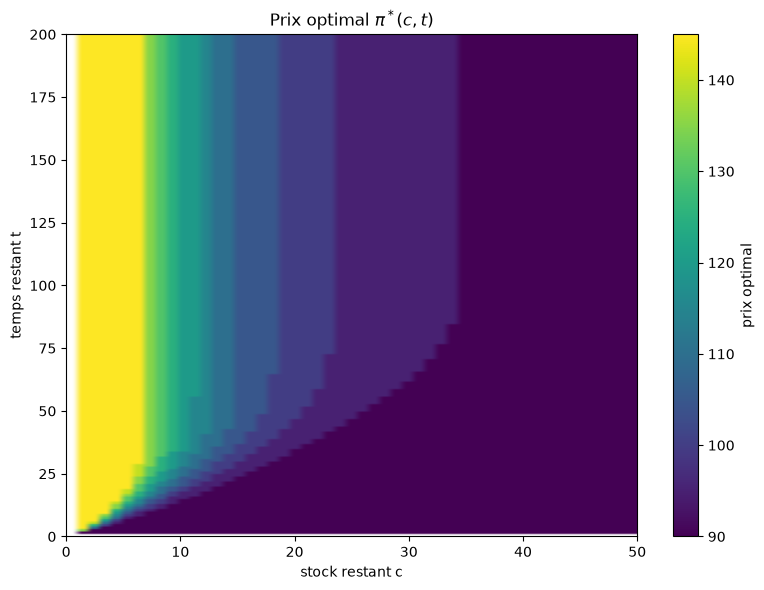

In [4]:
from src.dp import plot_price_heatmap

fig = plot_price_heatmap(pi_idx, cfg, savepath=OUT / "price_heatmap.png")
plt.show()

## 1.4 Carte de chaleur du prix optimal — figure centrale

Les trois propriétés structurelles se lisent d'un coup d'œil : le prix décroît quand on se déplace vers le haut (stock $c$ croissant) et croît quand on se déplace vers la droite (temps restant $t$ croissant).

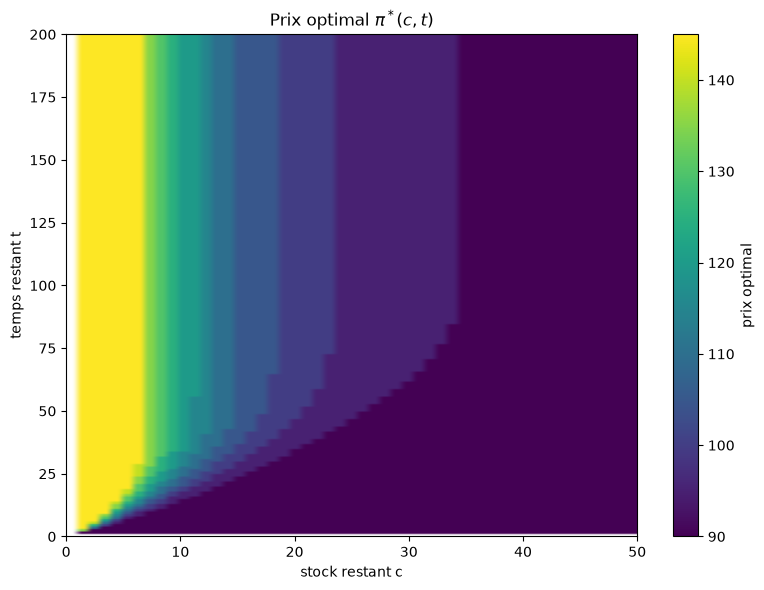

In [5]:
fig = plot_price_heatmap = __import__('src.dp', fromlist=['plot_price_heatmap']).plot_price_heatmap(
    pi_idx, cfg, savepath=OUT / "price_heatmap.png"
)
plt.show()

## 1.5 Bornes théoriques de sanité

$\|Q^*\|_\infty$ est borné par $p_{\max}/(1-\gamma)$.

In [6]:
bound = cfg.P_MAX / (1 - cfg.GAMMA)
print(f"max Q* = {Q_star.max():.2f}, borne théorique p_max/(1-gamma) = {bound:.2f}")
assert Q_star.max() <= bound + 1e-6

np.savez(OUT / "dp_solution.npz", Q_star=Q_star, V_star=V_star, pi_idx=pi_idx)
print("Solution DP sauvegardée dans outputs/dp_solution.npz")

max Q* = 986.52, borne théorique p_max/(1-gamma) = 2900.00
Solution DP sauvegardée dans outputs/dp_solution.npz
